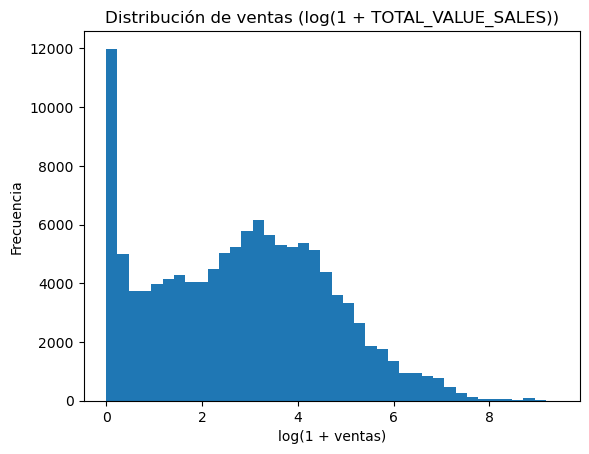

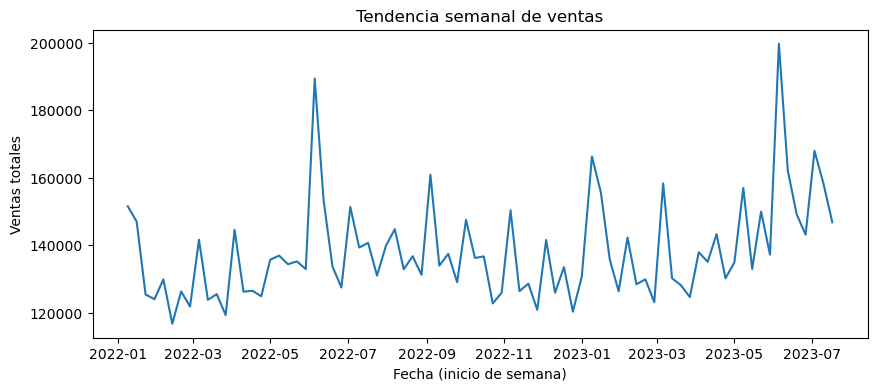

,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,ITEM_CODE_PAD,MANUFACTURER,BRAND,ITEM,...,ATTR1,ATTR2,ATTR3,SEGMENT,CATEGORY_ID,CATEGORY_y,DATE,YEAR,MONTH,WEEK_NUMBER
0,34-22,7501058792808BP2,0.006,0.139,1.000,TOTAL AUTOS AREA 5,7501058792808BP2,RECKITT,VANISH,7501058792808BP2,...,SAFE BLEACH,FABRIC TREATMENT,ROSA,POWDER,1.0,FABRIC TREATMENT and SANIT\r\n,2022-08-28,2022,8,34
1,34-22,7501058715883,0.487,116.519,2.916,TOTAL AUTOS AREA 5,0007501058715883,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2022-08-28,2022,8,34
2,34-22,7702626213774,1.391,68.453,5.171,TOTAL AUTOS AREA 5,0007702626213774,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2022-08-28,2022,8,34
3,34-22,7501058716422,0.022,1.481,1.833,TOTAL AUTOS AREA 5,0007501058716422,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2022-08-28,2022,8,34
4,34-22,7501058784353,2.037,182.839,5.375,TOTAL AUTOS AREA 5,0007501058784353,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2022-08-28,2022,8,34


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ====== CARGA ======
fact = pd.read_csv("FACT_SALES.csv")
prod = pd.read_excel("DIM_PRODUCT.xlsx")
seg  = pd.read_excel("DIM_SEGMENT.xlsx")
cat  = pd.read_csv("DIM_CATEGORY.csv")
cal  = pd.read_excel("DIM_CALENDAR.xlsx")

# ====== LIMPIEZA / TIPOS ======
fact = fact.drop_duplicates()
fact["TOTAL_VALUE_SALES"] = pd.to_numeric(fact["TOTAL_VALUE_SALES"], errors="coerce")
fact = fact.dropna(subset=["WEEK", "ITEM_CODE", "TOTAL_VALUE_SALES"])

# WEEK como texto para unir con calendario
fact["WEEK"] = fact["WEEK"].astype(str).str.strip()
cal["WEEK"]  = cal["WEEK"].astype(str).str.strip()
cal["DATE"]  = pd.to_datetime(cal["DATE"], errors="coerce")

# ITEM_CODE vs ITEM (PRODUCT) 
fact["ITEM_CODE"] = fact["ITEM_CODE"].astype(str).str.replace(r"\.0$", "", regex=True).str.strip()
prod["ITEM"]      = prod["ITEM"].astype(str).str.strip()

pad_len = prod["ITEM"].str.len().max()          # largo típico del ITEM en DIM_PRODUCT
fact["ITEM_CODE_PAD"] = fact["ITEM_CODE"].str.zfill(pad_len)

# ====== MERGES (ROBUSTOS) ======
df = fact.merge(prod, left_on="ITEM_CODE_PAD", right_on="ITEM", how="left")

# merge con DIM_SEGMENT 
possible_keys = ["CATEGORY", "FORMAT", "ATTR1", "ATTR2", "ATTR3"]
keys = [k for k in possible_keys if (k in df.columns) and (k in seg.columns)]
df = df.merge(seg, on=keys, how="left")

# merge con DIM_CATEGORY (ID_CATEGORY <-> CATEGORY)
df = df.merge(cat.rename(columns={"ID_CATEGORY": "CATEGORY_ID"}), left_on="CATEGORY", right_on="CATEGORY_ID", how="left")

# merge con CALENDAR para tener fecha real
df = df.merge(cal[["WEEK", "DATE", "YEAR", "MONTH", "WEEK_NUMBER"]], on="WEEK", how="left")

# ====== GRAFICAS  ======
# 1) Histograma ventas
plt.figure()
plt.hist(np.log1p(df["TOTAL_VALUE_SALES"].dropna()), bins=40)
plt.title("Distribución de ventas (log(1 + TOTAL_VALUE_SALES))")
plt.xlabel("log(1 + ventas)")
plt.ylabel("Frecuencia")
plt.show()

# 2) Tendencia semanal (por DATE del calendario)
ventas_semanales = df.groupby("DATE", as_index=False)["TOTAL_VALUE_SALES"].sum().dropna().sort_values("DATE")

plt.figure(figsize=(10,4))
plt.plot(ventas_semanales["DATE"], ventas_semanales["TOTAL_VALUE_SALES"])
plt.title("Tendencia semanal de ventas")
plt.xlabel("Fecha (inicio de semana)")
plt.ylabel("Ventas totales")
plt.show()

df.head()


C:\Users\tachi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\tachi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\tachi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\tachi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

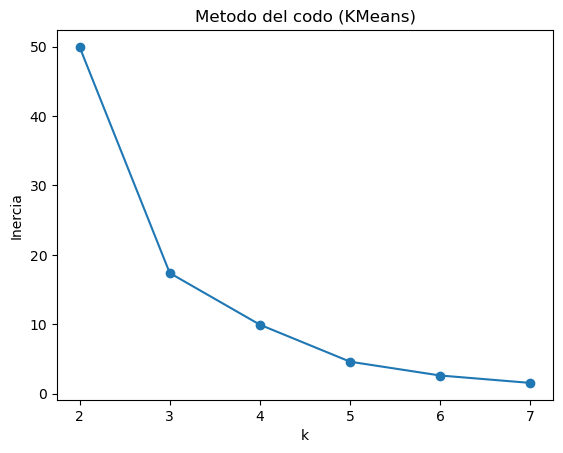

C:\Users\tachi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


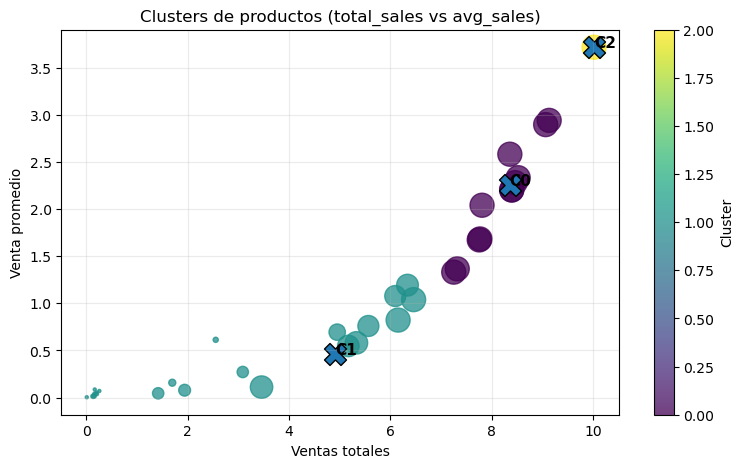

,ITEM,total_sales,avg_sales,transactions,cluster
0,7501025405298BP2,0.220,0.055000,4,1
1,7501025441326BP2,0.008,0.004000,2,1
2,7501025441487BP1,0.140,0.014000,10,1
3,7501025441487BP2,0.164,0.016400,10,1
4,7501025450984BP1,260.630,1.138122,229,1


In [38]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
import numpy as np
import matplotlib.pyplot as plt

# codo rapido
inertias = []
ks = range(2, 8)
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure()
plt.plot(list(ks), inertias, marker="o")
plt.title("Metodo del codo (KMeans)")
plt.xlabel("k")
plt.ylabel("Inercia")
plt.show()

# k simple 
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_df["cluster"] = kmeans.fit_predict(X_scaled)

# ====== VISUALIZACIÓN MEJORADA DE CLUSTERS ======
# (1) Escalas log para que no aplasten los puntos por outliers
x = np.log1p(cluster_df["total_sales"])
y = np.log1p(cluster_df["avg_sales"])

plt.figure(figsize=(9, 5))
sc = plt.scatter(
    x, y,
    c=cluster_df["cluster"],
    s=np.clip(cluster_df["transactions"], 5, 300),  # tamaño por #transacciones (sin inventar, ya existe)
    alpha=0.75
)

plt.title("Clusters de productos (total_sales vs avg_sales)")
plt.xlabel("Ventas totales")
plt.ylabel("Venta promedio")

# (2) Mostrar centroides en el mismo espacio (log) para interpretarlos
centers = kmeans.cluster_centers_  # están en espacio escalado
centers_unscaled = StandardScaler().fit(cluster_df[["total_sales","avg_sales","transactions"]]).inverse_transform(centers)

cx = np.log1p(centers_unscaled[:, 0])
cy = np.log1p(centers_unscaled[:, 1])

plt.scatter(cx, cy, marker="X", s=250, edgecolor="k")
for i, (px, py) in enumerate(zip(cx, cy)):
    plt.text(px, py, f"C{i}", fontsize=11, weight="bold")

# (3) Barra de color para saber qué número corresponde a qué cluster
cbar = plt.colorbar(sc)
cbar.set_label("Cluster")

plt.grid(True, alpha=0.25)
plt.show()


cluster_df.head()

MAE: 5049.1053265621495
MSE: 35956852.59246069


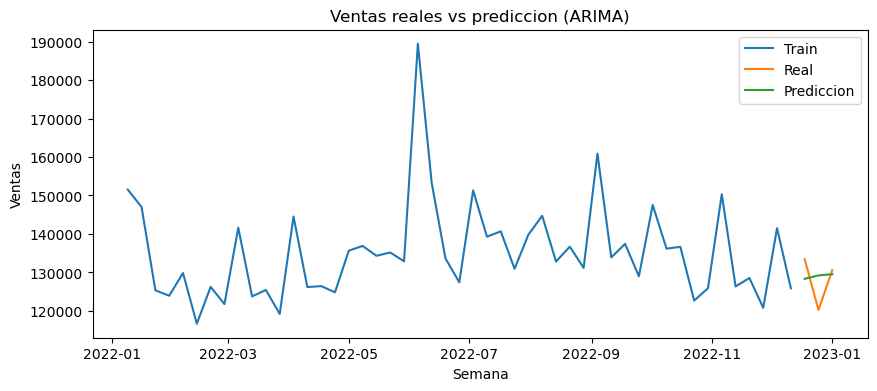

In [39]:
# -------- 2) PREDICCION (ARIMA) sobre serie semanal --------
# Serie con fecha semanal (DATE) ya viene de ventas_semanales
serie = ventas_semanales.set_index("DATE")["TOTAL_VALUE_SALES"].sort_index()
serie = serie.asfreq("W-SUN")
serie = serie.dropna()   


train = serie.iloc[:-3]
test  = serie.iloc[-3:]

model = ARIMA(train, order=(1,1,1))
fit = model.fit()

pred = fit.forecast(steps=len(test))

print("MAE:", mean_absolute_error(test, pred))
print("MSE:", mean_squared_error(test, pred))

plt.figure(figsize=(10,4))
plt.plot(train.index, train.values, label="Train")
plt.plot(test.index, test.values, label="Real")
plt.plot(test.index, pred.values, label="Prediccion")
plt.title("Ventas reales vs prediccion (ARIMA)")
plt.xlabel("Semana")
plt.ylabel("Ventas")
plt.legend()
plt.show()

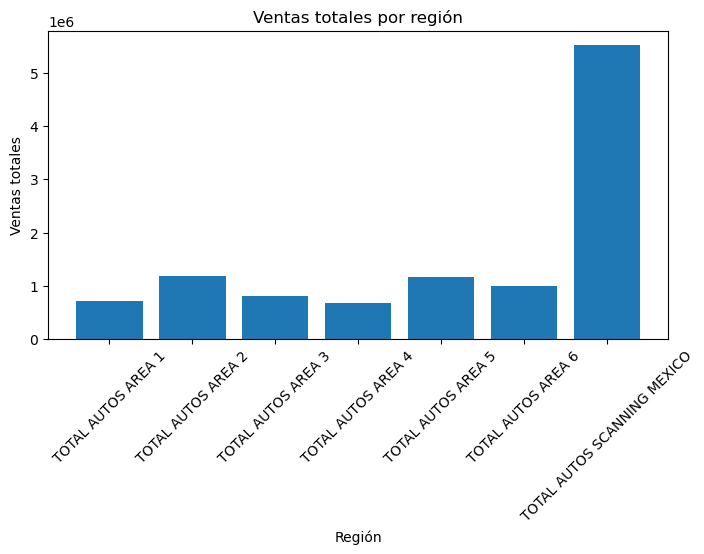

In [40]:
# ====== GRAFICA 1: Ventas por REGION ======
ventas_region = df.groupby("REGION", as_index=False)["TOTAL_VALUE_SALES"].sum()

plt.figure(figsize=(8,4))
plt.bar(ventas_region["REGION"], ventas_region["TOTAL_VALUE_SALES"])
plt.title("Ventas totales por región")
plt.xlabel("Región")
plt.ylabel("Ventas totales")
plt.xticks(rotation=45)
plt.show()
